# CIFAR-10 Image Classification
## ANN vs CNN — Architecture Comparison & Training Strategies

**Dataset:** CIFAR-10 — 60,000 color images (32×32×3), 10 classes
**Goal:** Build, compare, and improve ANN and CNN classifiers


### Problem Statement
CIFAR-10 contains 50,000 training and 10,000 test images across 10 classes:
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

We build an ANN and a CNN, compare their performance, then apply training strategies
(dropout, batch normalization, data augmentation, early stopping) to improve results.


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)


2026-06-19 06:14:49.920776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781849690.148056      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781849690.217949      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781849690.770701      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781849690.770740      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781849690.770742      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


## 1. Load Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape: ", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1755s 10us/step
Train shape: (50000, 32, 32, 3)
Test shape:  (10000, 32, 32, 3)


## 2. Visualize Sample Images

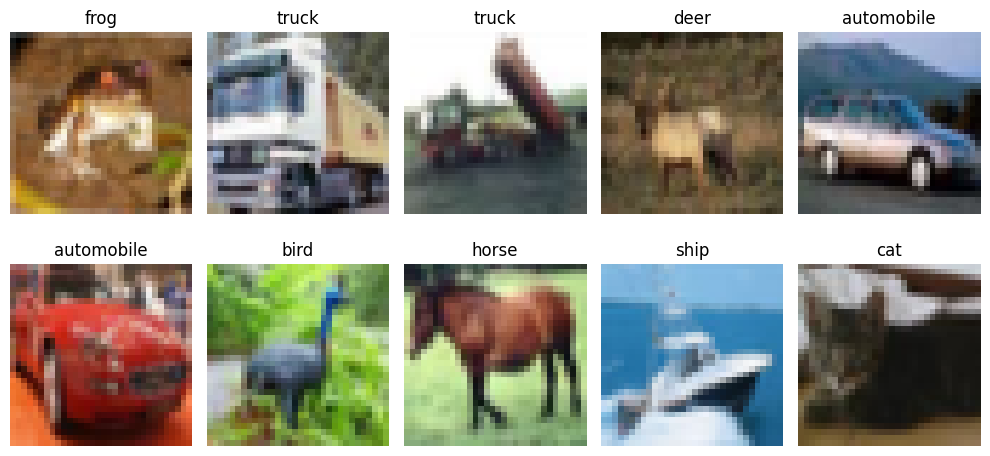

In [3]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()


## 3. Preprocessing — Normalize pixel values 0–255 → 0–1

In [4]:
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm),  -1)

print("Flat shape for ANN:", x_train_flat.shape)
print("3D shape for CNN: ", x_train_norm.shape)


Flat shape for ANN: (50000, 3072)
3D shape for CNN:  (50000, 32, 32, 3)


## 4. ANN Model
ANN flattens images into 1D vectors (3072 values), losing all spatial structure.
Dense layers learn pixel-level patterns but cannot capture edges, textures, or shapes.


In [13]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", round(ann_test_acc, 4))


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.2230 - loss: 2.0655 - val_accuracy: 0.3198 - val_loss: 1.9102
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2874 - loss: 1.9177 - val_accuracy: 0.3322 - val_loss: 1.8627
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3075 - loss: 1.8761 - val_accuracy: 0.3426 - val_loss: 1.8376
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3181 - loss: 1.8505 - val_accuracy: 0.3624 - val_loss: 1.7971
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3314 - loss: 1.8274 - val_accuracy: 0.3650 - val_loss: 1.8069
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3368 - loss: 1.8062 - val_accuracy: 0.3710 - val_loss: 1.7622
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3471 - loss: 1.7934 - val_accuracy: 0.3770 - val_loss: 1.7603
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3510 - loss: 1.7814 - val_accuracy: 0.

## 5. CNN Model
CNN preserves spatial structure through Conv2D layers that learn local patterns
(edges → textures → shapes → objects). BatchNorm stabilizes training,
MaxPooling reduces spatial dimensions, Dropout prevents overfitting.


In [19]:
cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", round(cnn_test_acc, 4))


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.4727 - loss: 1.5589 - val_accuracy: 0.5570 - val_loss: 1.2468
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6212 - loss: 1.0815 - val_accuracy: 0.6004 - val_loss: 1.1416
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6826 - loss: 0.9153 - val_accuracy: 0.6724 - val_loss: 0.9293
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7212 - loss: 0.7996 - val_accuracy: 0.6774 - val_loss: 0.9316
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7485 - loss: 0.7143 - val_accuracy: 0.6566 - val_loss: 1.0411
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7748 - loss: 0.6378 - val_accuracy: 0.6948 - val_loss: 0.8763
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7958 - loss: 0.5751 - val_accuracy: 0.7448 - val_loss: 0.7700
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8148 - loss: 0.5130 - val_accuracy: 0

## 6. Compare Learning Curves — ANN vs CNN

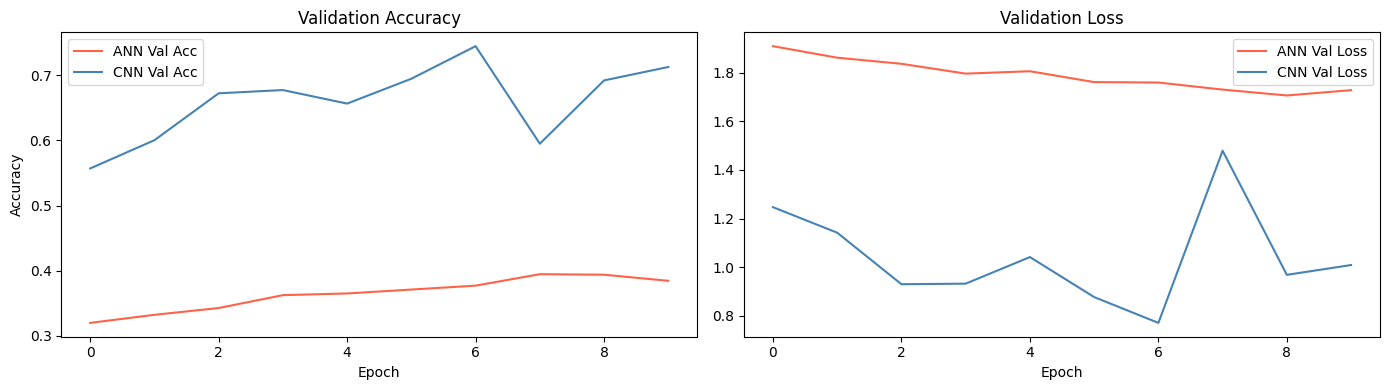

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ann_history.history['val_accuracy'], label='ANN Val Acc', color='tomato')
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN Val Acc', color='steelblue')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(ann_history.history['val_loss'], label='ANN Val Loss', color='tomato')
axes[1].plot(cnn_history.history['val_loss'], label='CNN Val Loss', color='steelblue')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Advanced CNN — Data Augmentation + EarlyStopping (20 epochs)
Data augmentation artificially expands the training set by applying random
transformations — making the model more robust to unseen variations.
EarlyStopping halts training when validation loss stops improving, preventing overfitting.


In [22]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop   = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop, lr_scheduler]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", round(aug_test_acc, 4))

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4117 - loss: 1.7379 - val_accuracy: 0.4726 - val_loss: 1.5184 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5134 - loss: 1.3681 - val_accuracy: 0.5856 - val_loss: 1.1762 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5594 - loss: 1.2471 - val_accuracy: 0.5786 - val_loss: 1.1906 - learning_rate: 0.0010
Epoch 4/20
700/704 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5880 - loss: 1.1740
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5903 - loss: 1.1674 - val_accuracy: 0.5718 - val_loss: 1.2777 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6322 - loss: 1.0501 - val_accuracy: 0.6656 - val_loss: 0.9377 - learning_rate: 5.0000e-04
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6458 - loss: 1.01

## 8. Final Comparison

,Model,Test Accuracy
0,ANN,0.3881
1,CNN,0.6979
2,CNN + Augmentation,0.7414


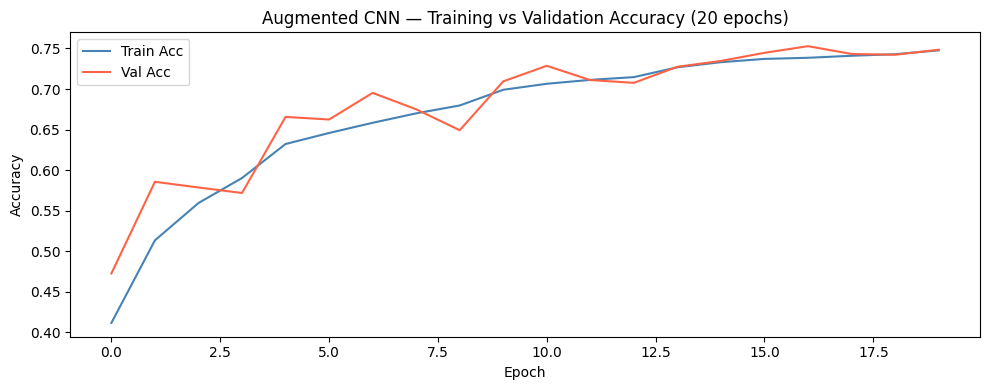

In [23]:
comparison = pd.DataFrame({
    'Model':         ['ANN', 'CNN', 'CNN + Augmentation'],
    'Test Accuracy': [round(ann_test_acc, 4),
                      round(cnn_test_acc, 4),
                      round(aug_test_acc, 4)]
})
display(comparison)

plt.figure(figsize=(10, 4))
plt.plot(aug_history.history['accuracy'],     label='Train Acc', color='steelblue')
plt.plot(aug_history.history['val_accuracy'], label='Val Acc',   color='tomato')
plt.title('Augmented CNN — Training vs Validation Accuracy (20 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


## 9. Confusion Matrix — CNN vs ANN

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


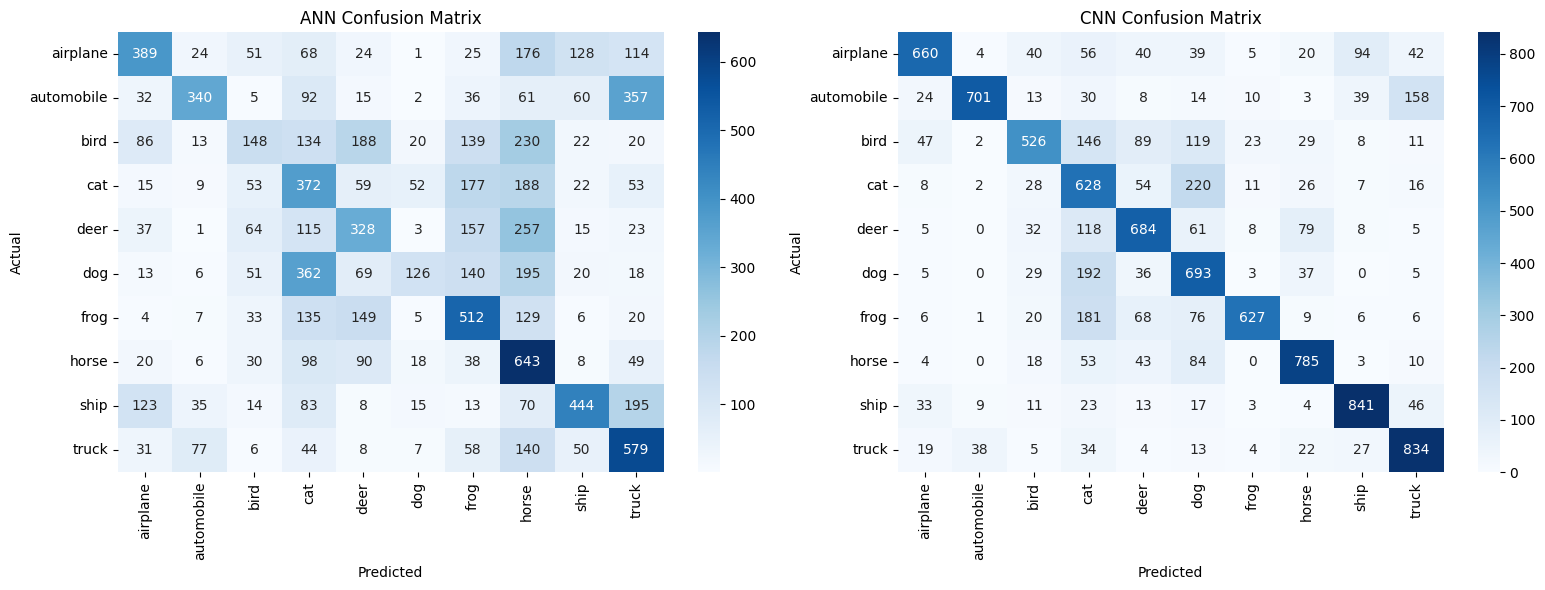

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, X, title in [
    (axes[0], ann_model, x_test_flat, 'ANN Confusion Matrix'),
    (axes[1], cnn_model, x_test_norm,  'CNN Confusion Matrix')
]:
    preds = model.predict(X).argmax(axis=1)
    cm    = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


## Conclusion

- **ANN** (1024→512→256→128, 3.8M params) flattens 32×32×3 images into 3,072-dimensional vectors, treating each pixel independently — test accuracy **38.81%**. Without spatial context, dense layers cannot learn meaningful visual patterns from CIFAR-10.
- **CNN** (32→64→128 filters, BatchNorm + MaxPooling, 357K params) preserves local spatial relationships through convolutional filters, learning edges → textures → object parts hierarchically — test accuracy **69.79%**, nearly double the ANN despite using 10× fewer parameters.
- **CNN + Data Augmentation + ReduceLROnPlateau** ran all 20 epochs with the LR reducing 4 times (0.001 → 0.0000625), steadily improving to test accuracy **74.14%**. Augmentation forced the model to learn invariant features; adaptive LR scheduling prevented stagnation.
- The confusion matrix confirms CNN classifies all 10 classes far more consistently than ANN. ANN struggles most with visually similar classes (cat/dog, automobile/truck), while CNN handles shape and texture differences more reliably.
- Weight sharing in convolutional layers means CNN achieves significantly higher accuracy with far fewer trainable parameters than the ANN — a core advantage of CNNs for image tasks.
